In [ ]:
import numpy as np
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

In [2]:
data = fetch_olivetti_faces(
    shuffle=True,
    random_state=42
)

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /home/shubham-singh/scikit_learn_data


In [4]:
X = data.data
y = data.target

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [6]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred = gnb.predict(X_test)

In [7]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

In [11]:
print(f'Accuracy: {accuracy*100:.2f}%')

Accuracy: 80.83%


In [12]:

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       1.00      1.00      1.00         2
           2       0.33      0.67      0.44         3
           3       0.00      0.00      0.00         5
           4       1.00      0.50      0.67         4
           5       1.00      1.00      1.00         2
           7       1.00      0.75      0.86         4
           8       1.00      0.67      0.80         3
           9       1.00      0.75      0.86         4
          10       1.00      1.00      1.00         3
          11       1.00      1.00      1.00         1
          12       0.40      1.00      0.57         4
          13       1.00      0.80      0.89         5
          14       1.00      0.40      0.57         5
          15       0.67      1.00      0.80         2
          16       1.00      0.67      0.80         3
          17       1.00      1.00      1.00         3
          18       1.00    

/home/shubham-singh/code/mllab/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/shubham-singh/code/mllab/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/shubham-singh/code/mllab/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{me

In [15]:
cross_val_score(
    gnb,
    X,
    y,
    cv=5
)

array([0.9   , 0.85  , 0.825 , 0.875 , 0.9125])

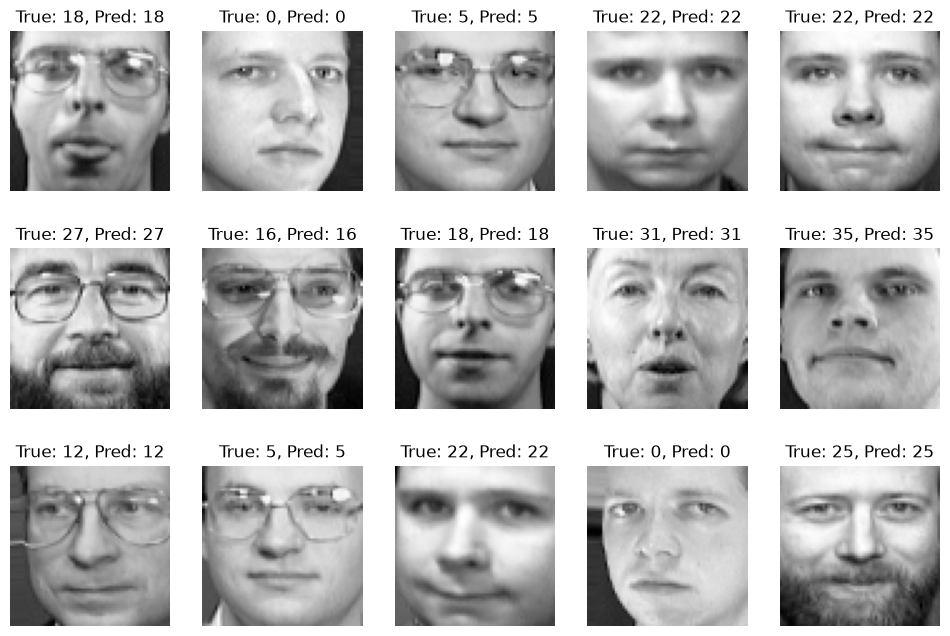

In [17]:
fig, axes = plt.subplots(
    3,
    5,
    figsize=(12,8)
)
for ax, image, label, prediction in zip(axes.ravel(), X_test, y_test, y_pred):
    ax.imshow(image.reshape(64,64), cmap=plt.cm.grey)
    ax.set_title(f"True: {label}, Pred: {prediction}")
    ax.axis('off')

plt.show()